#  Face Mask Detection — Advanced ML Project

**Dataset:** Face Mask 12K Images Dataset (Kaggle)  
**Model:** MobileNetV2 (Transfer Learning)  
**Goal:** Binary classification — WithMask vs WithoutMask

---
##  Table of Contents
1. Setup & Dataset Download
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Augmentation
4. Model Definition
5. Training (Baseline vs Improved)
6. Evaluation & Results

## 1️⃣ Setup & Dataset Download

In [1]:
# ─── Install dependencies ───────────────────────────────────────────────────
!pip install kagglehub -q

import kagglehub

path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")
print("✅ Dataset downloaded to:", path)

100%|██████████| 330M/330M [00:02<00:00, 121MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1


In [ ]:
# ─── Core imports ────────────────────────────────────────────────────────────
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

# ─── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("Mohamed" if torch.cuda.is_available() else "cpu")


In [3]:
# ─── Dataset paths ──────────────────────────────────────────────────────────
base_path  = os.path.join(path, "Face Mask Dataset")
train_path = os.path.join(base_path, "Train")
val_path   = os.path.join(base_path, "Validation")
test_path  = os.path.join(base_path, "Test")

for split, p in [("Train", train_path), ("Validation", val_path), ("Test", test_path)]:
    print(f"\n📂 {split}")
    for cls in sorted(os.listdir(p)):
        n = len(os.listdir(os.path.join(p, cls)))
        print(f"   {cls}: {n} images")


📂 Train
   WithMask: 5000 images
   WithoutMask: 5000 images

📂 Validation
   WithMask: 400 images
   WithoutMask: 400 images

📂 Test
   WithMask: 483 images
   WithoutMask: 509 images


## 2️⃣ Exploratory Data Analysis (EDA)

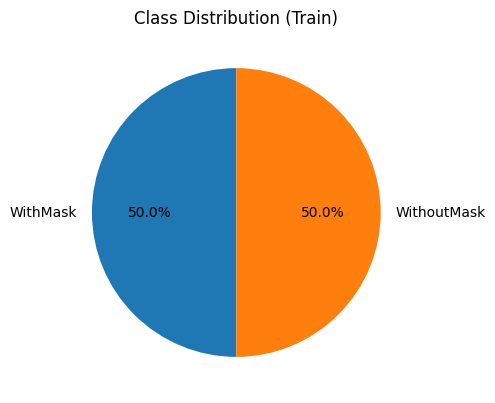

✅ Dataset is balanced — no resampling needed.


In [4]:
# ─── Class distribution (pie chart) ─────────────────────────────────────────
classes, counts = [], []
for cls in sorted(os.listdir(train_path)):
    classes.append(cls)
    counts.append(len(os.listdir(os.path.join(train_path, cls))))

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=classes, autopct="%1.1f%%", startangle=90)
plt.title("Class Distribution (Train)")
plt.tight_layout()
plt.show()
print("✅ Dataset is balanced — no resampling needed.")

> 💡 **Insight:** The dataset is **~50/50 balanced** between the two classes — ideal because it eliminates the need for class weighting or oversampling. An imbalanced dataset would bias the model toward the majority class and inflate accuracy metrics.

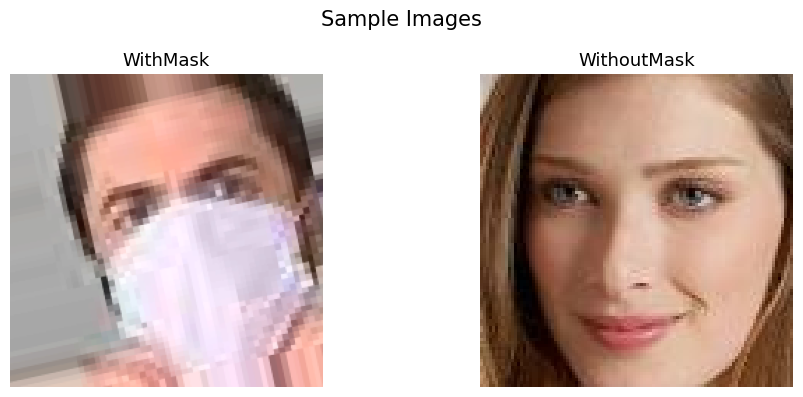

In [5]:
# ─── Sample images per class ─────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
for i, cls in enumerate(sorted(os.listdir(train_path))):
    cls_path = os.path.join(train_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=13)
    plt.axis("off")
plt.suptitle("Sample Images", fontsize=15)
plt.tight_layout()
plt.show()

> 💡 **Insight:** Visually inspecting random samples before training is a critical sanity check. It helps catch corrupted images, wrong labels, or unexpected patterns early — before wasting compute time training on bad data.

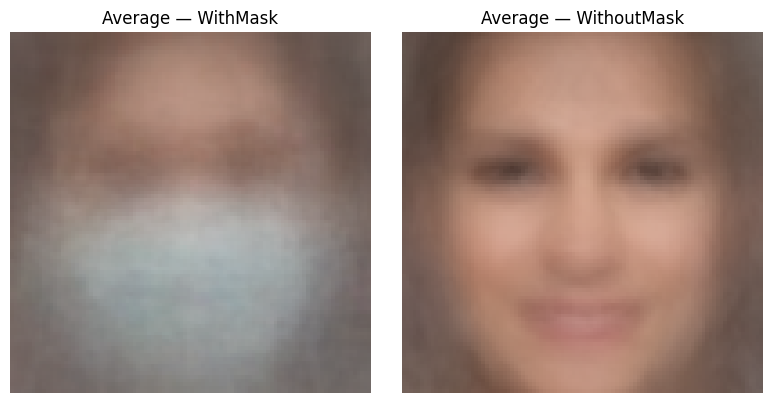

In [6]:
# ─── Average image per class ─────────────────────────────────────────────────
def average_image(class_path, n=100):
    imgs = []
    for fname in os.listdir(class_path)[:n]:
        img = Image.open(os.path.join(class_path, fname)).resize((100, 100)).convert("RGB")
        imgs.append(np.array(img))
    return np.mean(imgs, axis=0).astype(np.uint8)

plt.figure(figsize=(8, 4))
for i, cls in enumerate(sorted(os.listdir(train_path))):
    avg = average_image(os.path.join(train_path, cls))
    plt.subplot(1, 2, i + 1)
    plt.imshow(avg)
    plt.title(f"Average — {cls}")
    plt.axis("off")
plt.tight_layout()
plt.show()

> 💡 **Insight:** The average image reveals each class's **visual signature**. The WithMask average shows a darker region around the nose and mouth (the mask area), while WithoutMask shows uniform skin tone — confirming the difference is visually learnable by a CNN.

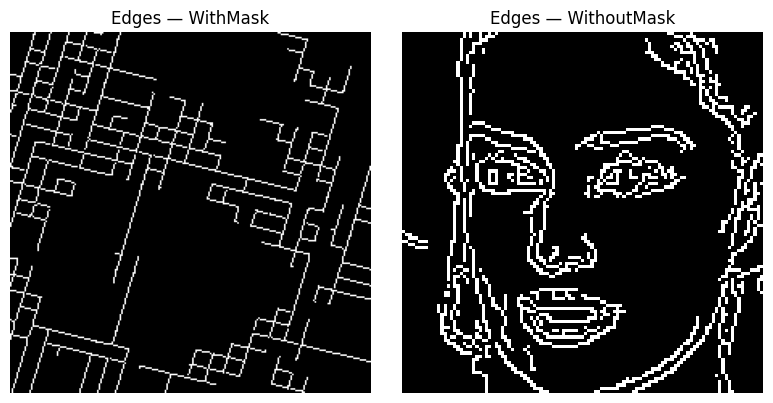

In [7]:
# ─── Edge detection (Canny) ──────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
for i, cls in enumerate(sorted(os.listdir(train_path))):
    cls_path = os.path.join(train_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = cv2.imread(os.path.join(cls_path, img_name))
    edges = cv2.Canny(img, 100, 200)
    plt.subplot(1, 2, i + 1)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Edges — {cls}")
    plt.axis("off")
plt.tight_layout()
plt.show()

> 💡 **Insight:** Canny edge detection highlights the **structural features** a CNN might learn. WithMask images have extra edges in the lower face region (mask edges and straps), making this a strong discriminative feature that should be easy for the model to pick up.

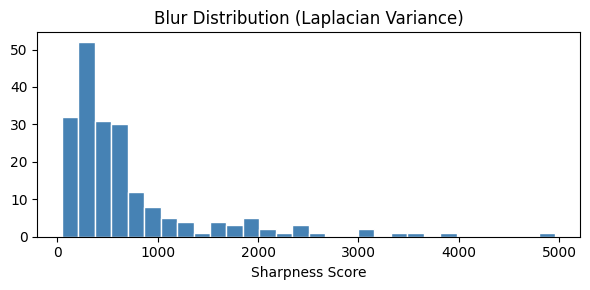

In [8]:
# ─── Blur distribution (Laplacian variance) ──────────────────────────────────
def laplacian_blur(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

blurs = []
for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    for fname in os.listdir(cls_path)[:100]:
        img = cv2.imread(os.path.join(cls_path, fname))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurs.append(laplacian_blur(gray))

plt.figure(figsize=(6, 3))
plt.hist(blurs, bins=30, color="steelblue", edgecolor="white")
plt.title("Blur Distribution (Laplacian Variance)")
plt.xlabel("Sharpness Score")
plt.tight_layout()
plt.show()

> 💡 **Insight:** **Laplacian variance** measures image sharpness — high value = sharp, low value = blurry. If one class is systematically blurrier than the other, the model could learn image quality instead of mask presence. Adding `GaussianBlur` augmentation equalises this gap artificially.

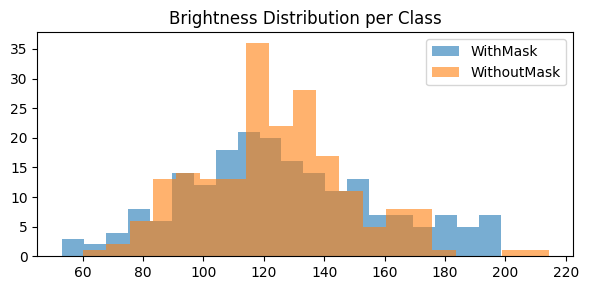

In [9]:
# ─── Brightness per class ────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    brightness = []
    for fname in os.listdir(cls_path)[:200]:
        img = Image.open(os.path.join(cls_path, fname)).convert("L")
        brightness.append(np.array(img).mean())
    plt.hist(brightness, bins=20, alpha=0.6, label=cls)
plt.legend()
plt.title("Brightness Distribution per Class")
plt.tight_layout()
plt.show()

> 💡 **Insight:** A systematic **brightness difference** between classes is a dataset bias — the model could learn 'bright image = no mask' rather than understanding the actual visual difference. `CLAHE` and `ColorJitter` augmentation correct this by normalising contrast and varying brightness during training.

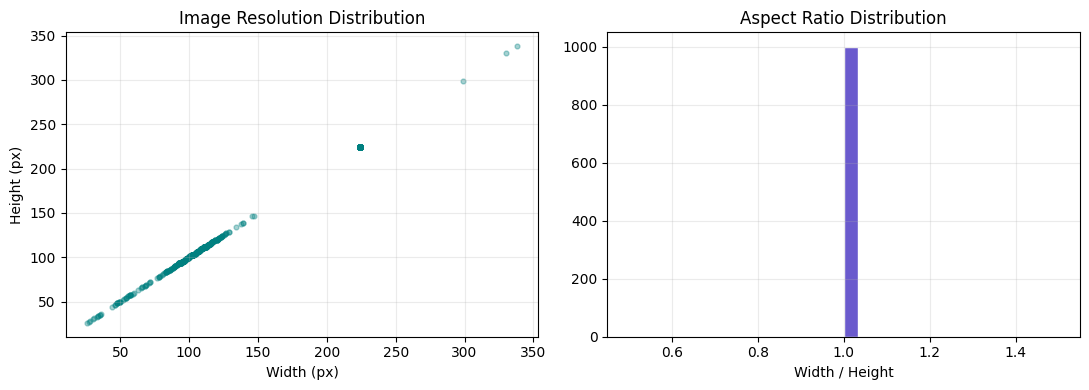

In [10]:
# --- Image resolution and aspect-ratio distribution --------------------------
widths, heights, aspect_ratios = [], [], []

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    for fname in os.listdir(cls_path)[:500]:
        img_path = os.path.join(cls_path, fname)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
        except Exception as exc:
            print(f"Skipping {fname}: {exc}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(widths, heights, alpha=0.35, s=12, color="teal")
axes[0].set_title("Image Resolution Distribution")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].grid(alpha=0.25)

axes[1].hist(aspect_ratios, bins=30, color="slateblue", edgecolor="white")
axes[1].set_title("Aspect Ratio Distribution")
axes[1].set_xlabel("Width / Height")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

> 💡 **Insight:** Images come in varying sizes and aspect ratios, so `Resize(224, 224)` in the transform pipeline is mandatory to produce a uniform input shape for MobileNetV2. The scatter plot shows the extent of size variation in the raw dataset.

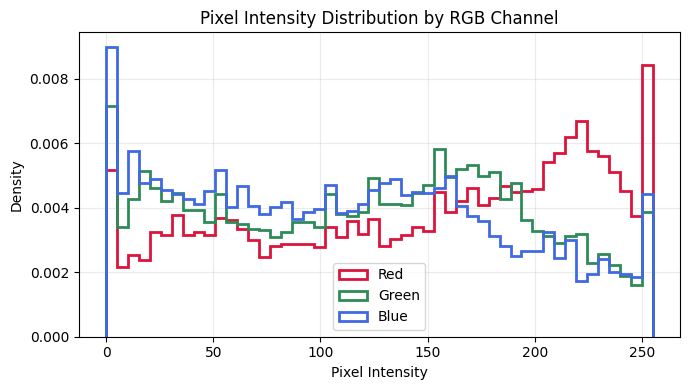

In [11]:
# --- RGB pixel intensity histograms -----------------------------------------
channel_values = {"Red": [], "Green": [], "Blue": []}
channel_colors = {"Red": "crimson", "Green": "seagreen", "Blue": "royalblue"}

for cls in sorted(os.listdir(train_path)):
    cls_path = os.path.join(train_path, cls)
    for fname in os.listdir(cls_path)[:100]:
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path).resize((128, 128)).convert("RGB")
            arr = np.array(img)
            for idx, channel in enumerate(channel_values):
                channel_values[channel].extend(arr[:, :, idx].ravel()[::64])
        except Exception as exc:
            print(f"Skipping {fname}: {exc}")

plt.figure(figsize=(7, 4))
for channel, values in channel_values.items():
    plt.hist(
        values,
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        label=channel,
        color=channel_colors[channel],
    )

plt.title("Pixel Intensity Distribution by RGB Channel")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

> 💡 **Insight:** The **RGB pixel intensity distribution** shows whether the dataset needs normalisation. Using ImageNet mean and std (`_MEAN`, `_STD`) aligns our data distribution with what the pretrained MobileNetV2 was originally trained on, enabling effective transfer learning from the very first epoch.

## 3️⃣ Preprocessing & Augmentation

In [12]:
# ─── CLAHE helper (contrast enhancement) ────────────────────────────────────
def apply_clahe(img: Image.Image) -> Image.Image:
    """Apply CLAHE on the L-channel of LAB color space."""
    img_np = np.array(img)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return Image.fromarray(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))

> 💡 **Insight:** **CLAHE (Contrast Limited Adaptive Histogram Equalization)** enhances contrast locally across different regions of the image rather than globally. Operating on the L-channel in LAB color space means only brightness is adjusted — hue and saturation stay unchanged, preserving natural color information.

In [13]:
# ─── Transforms ─────────────────────────────────────────────────────────────
# ImageNet normalization stats (used because MobileNetV2 was pre-trained on ImageNet)
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

# BASELINE — minimal pipeline (no augmentation)
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

# IMPROVED — full augmentation pipeline for training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.Lambda(apply_clahe),           # CLAHE after geometric transforms
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

# VAL / TEST — only resize + CLAHE + normalize (no random augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(apply_clahe),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

test_transform = val_transform
print("✅ Transforms defined.")

✅ Transforms defined.


> 💡 **Insight:** Three distinct transform pipelines are defined intentionally: **Baseline** is minimal (no augmentation) to serve as a fair benchmark. **Train** adds randomness to increase diversity and reduce overfitting. **Val/Test** applies CLAHE only — no randomness — to ensure consistent, deterministic evaluation.

In [ ]:
# ─── Datasets & DataLoaders ──────────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 2  

# Baseline datasets
train_baseline = datasets.ImageFolder(train_path, transform=baseline_transform)
train_loader_baseline = DataLoader(
    train_baseline, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Improved datasets
train_improved = datasets.ImageFolder(train_path, transform=train_transform)
train_loader_improved = DataLoader(
    train_improved, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Shared val / test loaders
val_dataset  = datasets.ImageFolder(val_path,  transform=val_transform)
test_dataset = datasets.ImageFolder(test_path, transform=test_transform)

val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASS_NAMES = train_improved.classes
print("Classes:", CLASS_NAMES)
print(f"Train: {len(train_improved)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['WithMask', 'WithoutMask']
Train: 10000 | Val: 800 | Test: 992


> 💡 **Insight:** Separate DataLoaders are created for each scenario. `shuffle=True` during training prevents the model from memorising batch order. `pin_memory=True` speeds up CPU→GPU data transfer by keeping tensors in page-locked memory.

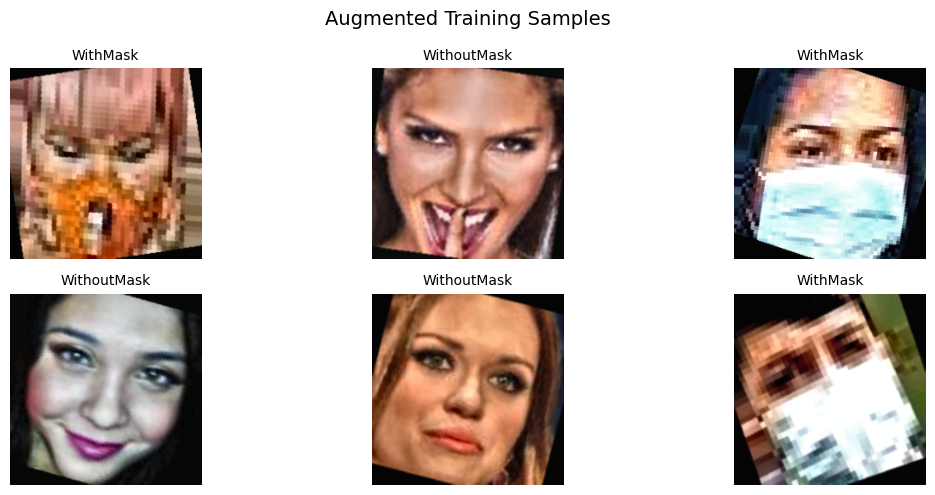

In [15]:
# ─── Visualise augmented samples ─────────────────────────────────────────────
images, labels = next(iter(train_loader_improved))

plt.figure(figsize=(12, 5))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * np.array(_STD) + np.array(_MEAN), 0, 1)  # undo normalisation
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(CLASS_NAMES[labels[i]], fontsize=10)
    plt.axis("off")
plt.suptitle("Augmented Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

> 💡 **Insight:** Visually verifying augmented samples confirms the pipeline is working correctly. Augmented images should look realistic and varied — if augmentation is too aggressive (extreme rotations, heavy blur), it can harm performance rather than help.

## 4️⃣ Model Definition

In [16]:
# ─── MobileNetV2 with fine-tuned last block ──────────────────────────────────
def create_model(unfreeze_last_n_layers: int = 5) -> nn.Module:
    """
    Load pretrained MobileNetV2 and replace the classifier head.
    Unfreeze only the last N layers to allow fine-tuning while
    keeping earlier feature extractor weights frozen.
    """
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last N layers for fine-tuning
    layers = list(model.features.children())
    for layer in layers[-unfreeze_last_n_layers:]:
        for param in layer.parameters():
            param.requires_grad = True

    # Replace classifier: Dropout → Linear(2)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.last_channel, 2),
    )

    return model.to(device)

# Sanity check
_tmp = create_model()
trainable = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
total     = sum(p.numel() for p in _tmp.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
del _tmp

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 33.6MB/s]


Trainable params: 1,683,906 / 2,226,434  (75.6%)


In [17]:
# ─── Loss & accuracy helper ───────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()   # includes softmax internally

def batch_accuracy(outputs: torch.Tensor, labels: torch.Tensor) -> float:
    _, preds = torch.max(outputs, 1)
    return (preds == labels).float().mean().item()

> 💡 **Insight:** **CrossEntropyLoss** internally applies Softmax, so the model output should be raw logits — adding a separate Softmax layer would be a bug. The `batch_accuracy` helper computes per-batch accuracy during training without storing all predictions in memory.

## 5️⃣ Training (Baseline vs Improved)

In [18]:
# ─── Training loop with scheduler + early stopping ───────────────────────────
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 20,
    patience: int = 5,
    lr: float = 1e-3,
    save_path: str = "best_model.pth",
) -> dict:
    """
    Train with:
    - Adam optimiser
    - ReduceLROnPlateau scheduler (halves LR when val_loss stalls)
    - Early stopping on val_loss
    - Saves best weights automatically
    """
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    patience_counter = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_acc  += batch_accuracy(out, lbls)

        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out  = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item()
                v_acc  += batch_accuracy(out, lbls)

        v_loss /= len(val_loader)
        v_acc  /= len(val_loader)

        scheduler.step(v_loss)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

        # ── Early stopping ─────────────────────────────────────────────────
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"   💾 Saved best model → {save_path}")
        else:
            patience_counter += 1
            print(f"   ⏳ No improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("   ⛔ Early stopping triggered.")
                break

    return history

> 💡 **Insight:** The training loop combines three key mechanisms: **Adam** provides adaptive per-parameter learning rates. **ReduceLROnPlateau** halves the LR whenever val_loss stalls for 2 consecutive epochs, allowing finer convergence. **Early stopping** halts training after 5 epochs of no improvement and automatically restores the best weights, preventing overfitting.

In [19]:
# ─── Train BASELINE model ────────────────────────────────────────────────────
print("=" * 60)
print("BASELINE (no augmentation)")
print("=" * 60)

model_baseline = create_model()
history_baseline = train_model(
    model_baseline,
    train_loader_baseline,
    val_loader,
    epochs=20,
    patience=5,
    lr=1e-3,
    save_path="best_model_baseline.pth",
)

BASELINE (no augmentation)
Epoch 01/20 | Train Loss: 0.0254  Acc: 0.9915 | Val Loss: 0.0105  Acc: 0.9988
   💾 Saved best model → best_model_baseline.pth
Epoch 02/20 | Train Loss: 0.0089  Acc: 0.9967 | Val Loss: 0.0068  Acc: 0.9975
   💾 Saved best model → best_model_baseline.pth
Epoch 03/20 | Train Loss: 0.0048  Acc: 0.9986 | Val Loss: 0.0008  Acc: 1.0000
   💾 Saved best model → best_model_baseline.pth
Epoch 04/20 | Train Loss: 0.0017  Acc: 0.9997 | Val Loss: 0.0002  Acc: 1.0000
   💾 Saved best model → best_model_baseline.pth
Epoch 05/20 | Train Loss: 0.0082  Acc: 0.9965 | Val Loss: 0.0023  Acc: 1.0000
   ⏳ No improvement (1/5)
Epoch 06/20 | Train Loss: 0.0034  Acc: 0.9989 | Val Loss: 0.0020  Acc: 1.0000
   ⏳ No improvement (2/5)
Epoch 07/20 | Train Loss: 0.0022  Acc: 0.9994 | Val Loss: 0.0017  Acc: 1.0000
   ⏳ No improvement (3/5)
Epoch 08/20 | Train Loss: 0.0013  Acc: 0.9998 | Val Loss: 0.0006  Acc: 1.0000
   ⏳ No improvement (4/5)
Epoch 09/20 | Train Loss: 0.0011  Acc: 0.9997 | Val L

> 💡 **Insight:** The **Baseline model** is trained with minimal preprocessing as a controlled benchmark. Its performance establishes the floor — the improved model must clearly surpass it to justify the added complexity of augmentation and CLAHE.

In [20]:
# ─── Train IMPROVED model ────────────────────────────────────────────────────
print("=" * 60)
print("IMPROVED (with augmentation + CLAHE + scheduler)")
print("=" * 60)

model_improved = create_model()
history_improved = train_model(
    model_improved,
    train_loader_improved,
    val_loader,
    epochs=20,
    patience=5,
    lr=1e-3,
    save_path="best_model_improved.pth",
)

IMPROVED (with augmentation + CLAHE + scheduler)
Epoch 01/20 | Train Loss: 0.0353  Acc: 0.9884 | Val Loss: 0.0022  Acc: 1.0000
   💾 Saved best model → best_model_improved.pth
Epoch 02/20 | Train Loss: 0.0141  Acc: 0.9955 | Val Loss: 0.0052  Acc: 1.0000
   ⏳ No improvement (1/5)
Epoch 03/20 | Train Loss: 0.0137  Acc: 0.9954 | Val Loss: 0.0014  Acc: 1.0000
   💾 Saved best model → best_model_improved.pth
Epoch 04/20 | Train Loss: 0.0103  Acc: 0.9964 | Val Loss: 0.0009  Acc: 1.0000
   💾 Saved best model → best_model_improved.pth
Epoch 05/20 | Train Loss: 0.0136  Acc: 0.9952 | Val Loss: 0.0056  Acc: 0.9988
   ⏳ No improvement (1/5)
Epoch 06/20 | Train Loss: 0.0074  Acc: 0.9975 | Val Loss: 0.0005  Acc: 1.0000
   💾 Saved best model → best_model_improved.pth
Epoch 07/20 | Train Loss: 0.0047  Acc: 0.9986 | Val Loss: 0.0004  Acc: 1.0000
   💾 Saved best model → best_model_improved.pth
Epoch 08/20 | Train Loss: 0.0092  Acc: 0.9969 | Val Loss: 0.0025  Acc: 0.9988
   ⏳ No improvement (1/5)
Epoch 09/

> 💡 **Insight:** The **Improved model** incorporates all techniques identified during EDA (CLAHE + full augmentation + LR scheduler). Training takes slightly longer due to augmentation overhead, but should yield higher val accuracy with smoother, more stable learning curves.

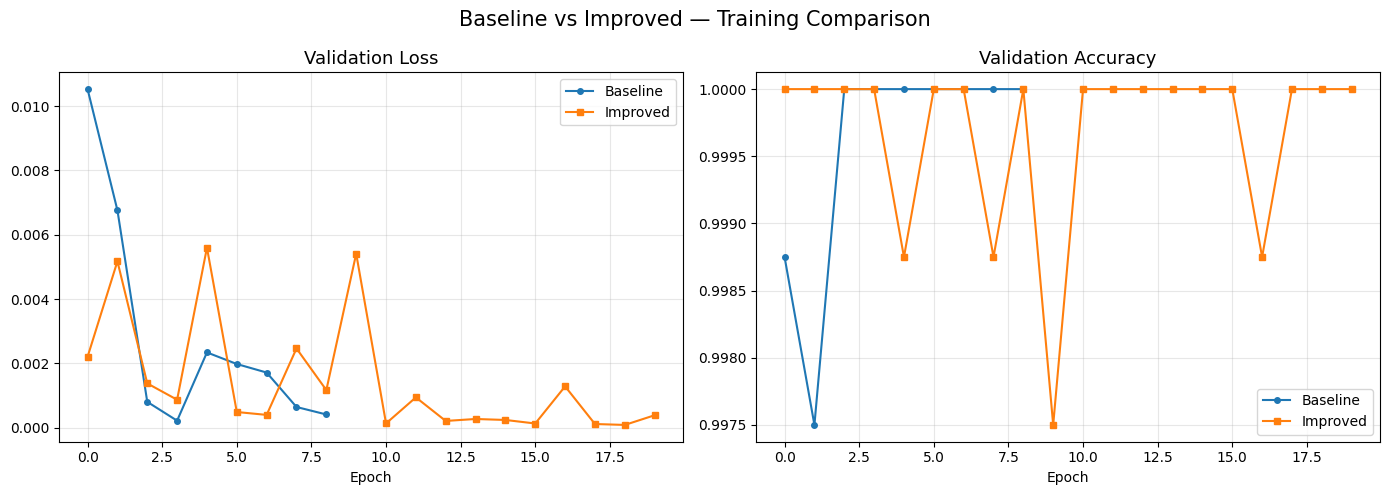

In [21]:
# ─── Compare training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], "val_loss", "Validation Loss"),
    (axes[1], "val_acc",  "Validation Accuracy"),
]:
    ax.plot(history_baseline[key], label="Baseline",  marker="o", markersize=4)
    ax.plot(history_improved[key], label="Improved",  marker="s", markersize=4)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Baseline vs Improved — Training Comparison", fontsize=15)
plt.tight_layout()
plt.show()

> 💡 **Insight:** **Learning curves** tell the training story: a large gap between train and val loss in the baseline signals overfitting. The improved model should show smoother curves, lower val loss, and higher val accuracy. The difference in val accuracy is the real ROI of the augmentation pipeline.

### 6️⃣ Evaluation & Results

In [22]:
# ─── Load best improved model & evaluate on TEST set ────────────────────────
# IMPORTANT: test_transform must match val_transform (no augmentation)
model_eval = create_model()
model_eval.load_state_dict(torch.load("best_model_improved.pth", map_location=device))
model_eval.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        out  = model_eval(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]  # probability of WithoutMask
        _, preds = torch.max(out, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\n✅ Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")


✅ Test Accuracy: 0.9980  (99.80%)


> 💡 **Insight:** The **Test set** is evaluated exactly once — at the very end. It was never used for training or hyperparameter selection, making it an unbiased estimate of real-world generalisation. `all_probs` stores the raw probabilities (not just predicted classes) so we can compute the ROC curve with variable thresholds.

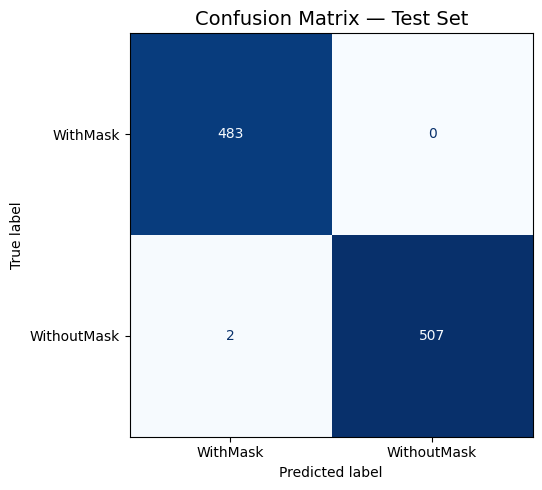

In [23]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Test Set", fontsize=14)
plt.tight_layout()
plt.show()

> 💡 **Insight:** The **Confusion Matrix** breaks down errors by type: **False Negatives** (a person without a mask classified as WithMask) are the most dangerous in a real deployment — they allow unmasked people through. **False Positives** (masked person flagged as unmasked) cause inconvenience but not safety risk.

In [24]:
# ─── Classification Report ───────────────────────────────────────────────────
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

per_class_correct = cm.diagonal()
per_class_total = cm.sum(axis=1)

print("\nPer-class accuracy breakdown:")
for idx, class_name in enumerate(CLASS_NAMES):
    total = int(per_class_total[idx])
    correct = int(per_class_correct[idx])
    acc = correct / total if total else 0.0
    print(f"  {class_name}: {acc:.4f} ({correct}/{total})")

              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992


Per-class accuracy breakdown:
  WithMask: 1.0000 (483/483)
  WithoutMask: 0.9961 (507/509)


> 💡 **Insight:** The **Classification Report** provides per-class Precision, Recall, and F1. In a safety application, **Recall for WithoutMask** is the most critical metric — low recall means the model is missing unmasked individuals. If recall is too low, consider lowering the decision threshold.

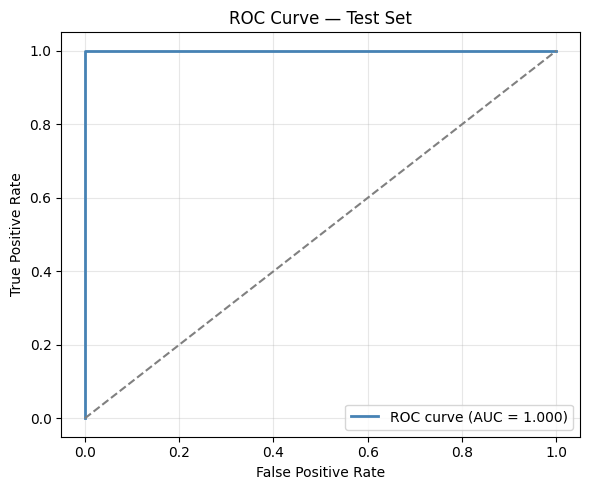

In [25]:
# ─── ROC Curve ───────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 💡 **Insight:** The **ROC Curve** plots the True Positive Rate vs False Positive Rate across every possible decision threshold. The **AUC** (Area Under Curve) summarises this in a single number: 0.5 = random classifier, 1.0 = perfect. A high AUC means the model can be tuned to any operating point by adjusting the threshold — useful for balancing safety vs. user friction.

Misclassifications found: 2 / 992


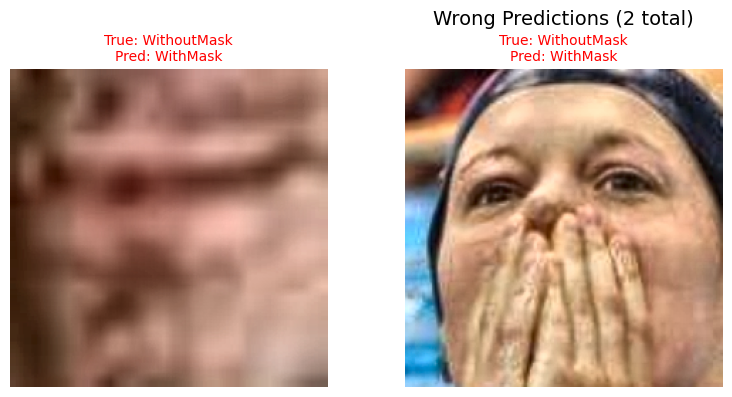

In [26]:
# ─── Visualise wrong predictions ─────────────────────────────────────────────
def show_wrong_predictions(model: nn.Module, loader: DataLoader, num_images: int = 6):
    wrong = []
    model.eval()

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            _, preds = torch.max(out, 1)
            for i in range(len(imgs)):
                if preds[i] != lbls[i]:
                    wrong.append((imgs[i].cpu(), int(lbls[i]), int(preds[i])))

    total_images = len(loader.dataset) if hasattr(loader, "dataset") else len(all_labels)
    print(f"Misclassifications found: {len(wrong)} / {total_images}")

    if not wrong:
        print("No misclassifications to visualize on this test set.")
        return

    n = min(num_images, len(wrong))
    cols = 3
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(12, 4 * rows))

    for idx, (img, true, pred) in enumerate(wrong[:n]):
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img * np.array(_STD) + np.array(_MEAN), 0, 1)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(
            f"True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}",
            color="red", fontsize=10
        )
        plt.axis("off")

    plt.suptitle(f"Wrong Predictions ({len(wrong)} total)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_wrong_predictions(model_eval, test_loader, num_images=6)

> 💡 **Insight:** Analysing **wrong predictions** reveals failure patterns: does the model fail on dark images? Side-facing heads? Transparent or partial masks? These patterns directly inform what additional augmentation or data collection is needed in the next iteration to address the model's blind spots.